# LinearRegression
## 01. 선형회귀

경사하강법을 통해 손실함수를 줄이면서 최적의 직선을 찾는 과정을 직접 구현했다.

scikit-learn의 LinearRegression 클래스를 사용해 직접 미분과 반복 업데이트를 작성하지 않고도 선형회귀 모델을 학습하고 평가할 수 있다.

선형회귀는 종속 변수와 한 개 이상의 독립 변수 사이의 선형 관계를 모델링하는 방법이다.

1. 단순 선형회귀
독립 변수가 하나인 경우이다.

    $
    y = \beta_0 + \beta_1 x + \epsilon
    $

2. 다중 선형회귀
독립 변수가 여러 개인 경우이다.

    $
    y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_n x_n + \epsilon
    $

여기서,
- $y$: 종속 변수
- $x_1, x_2, \cdots, x_n$: 독립 변수
- $\beta_0$: 절편
- $\beta_1, \beta_2, \cdots, \beta_n$: 회귀계수
- $\epsilon$: 오차

### 보스턴 주택가격 회귀예측

여러 주택 관련 특성을 이용해 집값(MEDV)을 예측하는 회귀 문제를 다룬다.

1. 데이터의 구조를 확인한다.
2. 각 특성이 타겟과 어떤 관계를 가지는지 살펴본다.
3. 학습/평가 데이터로 나누어 모델을 학습한다.
4. 회귀 성능 지표와 회귀계수를 해석한다.

주요 컬럼 예시는 다음과 같다.

- CRIM: 지역 범죄율
- RM: 평균 방 개수
- PTRATIO: 학생-교사 비율
- LSTAT: 저소득층 비율
- MEDV: 주택 가격 중앙값

중요한 것은 각 컬럼의 사전적 의미를 모두 외우는 것이 아니라, 어떤 특성이 타겟과 양의 관계인지, 음의 관계인지, 그리고 직선으로 설명 가능한지 아닌지를 관찰하는 것이다.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
boston_housing_df = pd.read_csv('data/boston_housing_train.csv')
boston_housing_df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


In [3]:
boston_housing_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    float64
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(14)
memory usage: 55.5 KB


In [4]:
boston_housing_df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


### 특성과 타겟의 관계 시각화

회귀 문제에서는 모델을 바로 학습하기 전에 입력 변수와 타겟 사이의 관계를 먼저 눈으로 확인하는 습관이 중요하다.

regplot은 산점도와 회귀선을 함께 보여주므로 각 특성이 타겟과 대체로 어떤 방향의 관계를 가지는지 빠르게 파악할 수 있다.

1. 우상향인가, 우하향인가
2. 직선으로 설명 가능한가
3. 이상치가 많은가
4. 변수에 따라 관계 강도가 다른가

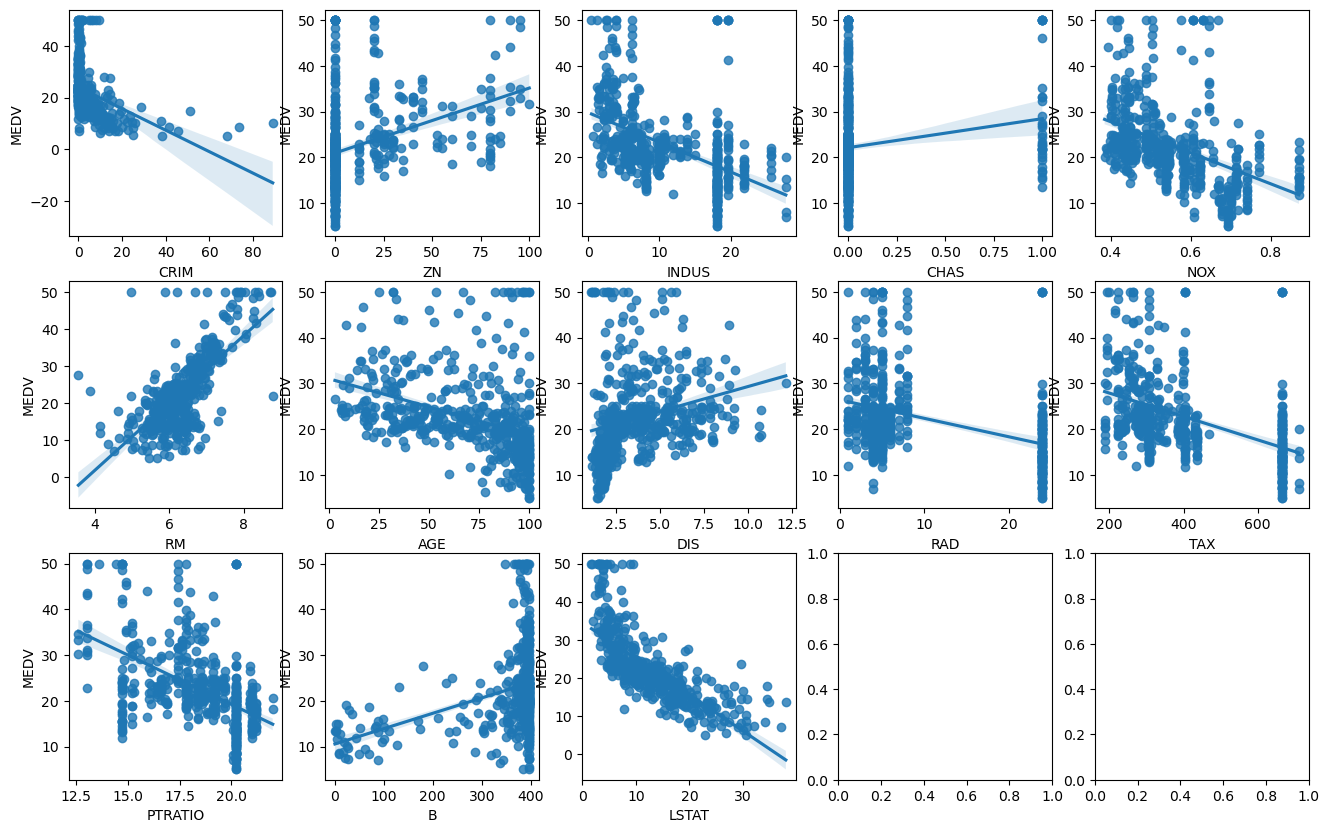

In [6]:
fig, ax = plt.subplots(3, 5, figsize=(16,10))
feature_names = boston_housing_df.columns[:-1]  # 타겟 데이터 제외 13개

for i, feature in enumerate(feature_names):
    row = i//5
    col = i % 5
    sns.regplot(x=feature, y='MEDV', data=boston_housing_df, ax=ax[row,col])
    
plt.show()

In [7]:
# 데이터 준비
from sklearn.model_selection import train_test_split

X = boston_housing_df[feature_names].to_numpy()
y = boston_housing_df['MEDV'].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(404, 13) (404,)
(102, 13) (102,)


In [8]:
# 모델 학습/평가/예측
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [13]:
# 평가/예측
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error

print('학습셋 R^2:', lin_reg.score(X_train,y_train))
print('평가셋 R^2:', lin_reg.score(X_test, y_test))

print('학습셋 MAE:', mean_absolute_error(y_train, lin_reg.predict(X_train)))
print('평가셋 MAE:', mean_absolute_error(y_test, lin_reg.predict(X_test)))

print('학습셋 MSE:', mean_squared_error(y_train, lin_reg.predict(X_train)))
print('평가셋 MSE:', mean_squared_error(y_test, lin_reg.predict(X_test)))

print('학습셋 RMSE:', root_mean_squared_error(y_train, lin_reg.predict(X_train)))
print('평가셋 RMSE:', root_mean_squared_error(y_test, lin_reg.predict(X_test)))

학습셋 R^2: 0.7508856358979673
평가셋 R^2: 0.6687594935356318
학습셋 MAE: 3.3147716267832266
평가셋 MAE: 3.189091965887845
학습셋 MSE: 21.641412753226312
평가셋 MSE: 24.291119474973534
학습셋 RMSE: 4.6520331848801675
평가셋 RMSE: 4.928602182665338


## 02. 비선형회귀

위에서는 입력과 출력의 관계를 직선으로 설명하는 선형회귀를 다루었다.

하지만 실제 데이터는 항상 직선 형태로 움직이지 않는다. 초반에 급격히 증가하다가 완만해지기도 하고, 곡선 형태를 띠기도 하며, 특정 구간에서만 크게 변하기도 한다.

이럴 때는 입력 또는 타겟을 변환하거나, 다항식 특성을 추가하여 선형 모델이 곡선 패턴까지 학습하도록 만들 수 있다.

즉, 학습 알고리즘 자체는 선형회귀를 쓰더라도 데이터를 어떤 형태로 바꾸느냐에 따라 비선형적인 관계를 표현할 수 있다.

다음 세 가지를 확인한다.

1. 지수회귀
2. 로그회귀
3. 다항회귀

### 01. 지수회귀

지수회귀는 값이 기하급수적으로 증가하거나 감소하는 데이터를 다룰 때 사용한다.

대표 예시는 다음과 같다.

- 인구 증가
- 복리 성장
- 바이러스 확산
- 방사능 붕괴

기본 형태는 다음과 같다.

$
y = a e^{bx}
$

이 식은 그대로는 직선이 아니지만, 양변에 로그를 취하면 선형 형태로 바꿀 수 있다.

$
\log(y) = \log(a) + bx
$

즉, y를 로그 변환하면 선형회귀로도 지수 형태 데이터를 학습할 수 있다.

비선형 데이터를 직접 다른 모델로 바꾸는 것이 아니라, 변환을 통해 선형회귀로 다룰 수 있게 만든다는 점이다.

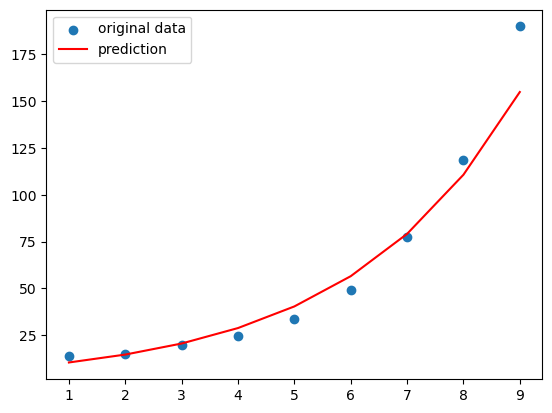

In [14]:
# 샘플 데이터 생성
x = np.arange(1, 10).reshape(-1, 1)
true_a, true_b = 2, 0.5

# 지수함수 형태로 데이터 생성 (기하 급수적 증가)
y = true_a * np.exp(true_b * x)
# 노이즈 추가
y += np.random.normal(loc=10, scale=1, size=x.shape)    # 평균 10, 표준편차 1안 정규분포 난수

# y에 log를 취한다 => 지수함수에 로그를 취하면 선형 형태가 되어 일반 회귀 모델 학습이 가능
log_y = np.log(y)

# 모델 학습: x와 변환 됨 log_y 로 학습
exp_model = LinearRegression()
exp_model.fit(x, log_y)

# 예측 및 복원
y_pred_log = exp_model.predict(x)   # 모델이 예측한 값은 로그 값
y_pred = np.exp(y_pred_log)         # 다시 지수함수를 씌워 원래의 y 단위로 복원

# 시각화
plt.scatter(x, y, label='original data')
plt.plot(x, y_pred, color='red', label='prediction')
plt.legend()
plt.show()

### 02. 로그회귀

로그회귀는 처음에는 빠르게 증가하지만 시간이 지날수록 증가폭이 완만해지는 패턴에 적합하다.

대표 예시는 다음과 같다.

- 학습 효과 곡선
- 광고비 증가에 따른 성과 증가
- 초반에는 빠르지만 점점 둔화되는 성장 패턴

기본 형태는 다음과 같다.

$
y = a + b \log(x)
$

이번에는 y를 변환하는 것이 아니라 x에 로그를 취해 입력 간격을 조정한다.

즉, 입력 쪽을 변환해서 원래 곡선 관계를 선형회귀가 다룰 수 있는 형태로 바꾸는 것이다.

지수회귀와 로그회귀의 차이는 어느 쪽 변수에 로그를 적용하느냐에 있다.

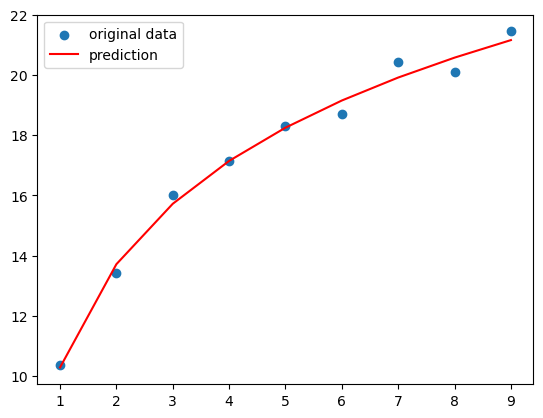

In [15]:
# 샘플 데이터 생성
x = np.arange(1, 10).reshape(-1, 1)
true_a, true_b = 10, 5

# 로그함수 형태로 데이터 생성 (증가폭이 점점 둔화)
y = true_a + true_b * np.log(x)
# 노이즈 추가
y += np.random.normal(loc=0, scale=0.5, size=x.shape)    # 평균 10, 표준편차 1안 정규분포 난수

# x에 log를 취한다 => x축의 간격을 로그단위로 압축하여 선형 회귀 모델이 인식하게 좋게 변경함
log_x = np.log(x)

# 모델 학습: 변환된 log_x와 y 로 학습
exp_model = LinearRegression()
exp_model.fit(log_x, y)

# 예측 및 복원
y_pred = exp_model.predict(log_x)   # 입력 값에 log를 취해서 예측할 것

# 시각화
plt.scatter(x, y, label='original data')
plt.plot(x, y_pred, color='red', label='prediction')
plt.legend()
plt.show()

### 03. 다항회귀

다항회귀는 입력 특성에 제곱항, 세제곱항 같은 항을 추가하여 직선이 아닌 곡선 형태를 표현하는 방법이다.

예를 들어 단일 변수 x에 대해 다음과 같이 확장할 수 있다.

$
y = w_0 + w_1x + w_2x^2 + \cdots + w_dx^d
$

중요한 점은 알고리즘이 완전히 달라지는 것이 아니라, 입력 특성을 늘린 뒤 선형회귀를 적용한다는 것이다.

즉,
- 원래 특성: x
- 변환된 특성: x, x², x³ ...

처럼 입력을 확장해서 곡선 관계를 학습하게 만든다.

다항회귀는 표현력이 커지는 장점이 있지만, 차수를 너무 높이면 학습 데이터에만 과하게 맞는 과적합이 발생할 수 있다.

이 점이 이후 규제 선형 회귀와 연결된다.

In [18]:
from sklearn.preprocessing import PolynomialFeatures

def polynomial_func(X):
    """
    테스트용 정답 함수: y = 2 + 3*x1 + 4*x1^2 + 5*x2^2
    """
    return 2 + 3 * X[:,0] + 4 * X[:,0]**2 + 5 * X[:,1]**2

# 샘플 데이터 생성
X = np.arange(4).reshape(2, 2)
y = polynomial_func(X)
df = pd.DataFrame(X)
df['target'] = y
display(df)

# 다항식 전처리 : 특성을 늘려주는 도구 설정
# degree=2 : 제곱항까지 생성, include_bias=False: 1이라는 bias 빼고 생성
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)  # 데이터를 다항식 형태로 변환

print(X_poly.shape)
print(poly.get_feature_names_out())

# 모델 학습
lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)

# 평가 예측
input = [[3, 4],[5, 6]]
input_poly = poly.transform(input)  # 학습 시 사용한 도구를 이용하여 반환
prediction = lin_reg.predict(input_poly)
print(prediction)

,0,1,target
0,0,1,7
1,2,3,69


(2, 5)
['x0' 'x1' 'x0^2' 'x0 x1' 'x1^2']
[127. 297.]


In [28]:
# 다항 전처리 + 모델 : Pipeline을 이용한 공정 자동화
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error

pipeline = Pipeline([
    ('Poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('lin', LinearRegression())
])

# 전처리 + 모델 학습 : 내부적으로 poly.fit_transform() -> lin_fit() 연속 동작
pipeline.fit(X, y)

# 예측 poly.transform() -> lin.predict() 연속 동작
input = [[3,4],[5,6]]
print(pipeline.predict(input))

lin_ = pipeline.named_steps['lin']  # 'lin'이라는 이름의 모델 반환
# 학습 된 최종 결과
print('가중치:', lin_.coef_)
print('절편:',lin_.intercept_)

[127. 297.]
가중치: [1. 1. 2. 3. 4.]
절편: 1.9999999999999858


### 실제 데이터에 다항회귀 적용

앞에서는 작은 예제로 다항 특성 생성 원리를 확인했다.
이제 같은 개념을 실제 주택가격 데이터에 적용한다.

여기서 확인할 포인트는 다음과 같다.

1. 다항 특성을 만들면 입력 차원이 크게 늘어난다.
2. 모델의 표현력은 커질 수 있다.
3. 학습 성능이 좋아져도 평가 성능이 함께 좋아지는지 확인해야 한다.

즉, 성능 향상만 볼 것이 아니라 복잡해진 모델이 일반화에도 도움이 되는지 함께 판단해야 한다.

In [30]:
# 파이프라인 생성
pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('lin', LinearRegression())
])

# 모델 학습
pipeline.fit(X_train, y_train)

print(pipeline.named_steps['poly'].get_feature_names_out())

print(pipeline.named_steps['poly'].get_feature_names_out())
coef = pipeline.named_steps['lin'].coef_
print(coef)

['x0' 'x1' 'x2' 'x3' 'x4' 'x5' 'x6' 'x7' 'x8' 'x9' 'x10' 'x11' 'x12'
 'x0^2' 'x0 x1' 'x0 x2' 'x0 x3' 'x0 x4' 'x0 x5' 'x0 x6' 'x0 x7' 'x0 x8'
 'x0 x9' 'x0 x10' 'x0 x11' 'x0 x12' 'x1^2' 'x1 x2' 'x1 x3' 'x1 x4' 'x1 x5'
 'x1 x6' 'x1 x7' 'x1 x8' 'x1 x9' 'x1 x10' 'x1 x11' 'x1 x12' 'x2^2' 'x2 x3'
 'x2 x4' 'x2 x5' 'x2 x6' 'x2 x7' 'x2 x8' 'x2 x9' 'x2 x10' 'x2 x11'
 'x2 x12' 'x3^2' 'x3 x4' 'x3 x5' 'x3 x6' 'x3 x7' 'x3 x8' 'x3 x9' 'x3 x10'
 'x3 x11' 'x3 x12' 'x4^2' 'x4 x5' 'x4 x6' 'x4 x7' 'x4 x8' 'x4 x9' 'x4 x10'
 'x4 x11' 'x4 x12' 'x5^2' 'x5 x6' 'x5 x7' 'x5 x8' 'x5 x9' 'x5 x10'
 'x5 x11' 'x5 x12' 'x6^2' 'x6 x7' 'x6 x8' 'x6 x9' 'x6 x10' 'x6 x11'
 'x6 x12' 'x7^2' 'x7 x8' 'x7 x9' 'x7 x10' 'x7 x11' 'x7 x12' 'x8^2' 'x8 x9'
 'x8 x10' 'x8 x11' 'x8 x12' 'x9^2' 'x9 x10' 'x9 x11' 'x9 x12' 'x10^2'
 'x10 x11' 'x10 x12' 'x11^2' 'x11 x12' 'x12^2']
['x0' 'x1' 'x2' 'x3' 'x4' 'x5' 'x6' 'x7' 'x8' 'x9' 'x10' 'x11' 'x12'
 'x0^2' 'x0 x1' 'x0 x2' 'x0 x3' 'x0 x4' 'x0 x5' 'x0 x6' 'x0 x7' 'x0 x8'
 'x0 x9' 'x0 x10' 'x0 x1

In [31]:
print('학습셋 R^2:', pipeline.score(X_train,y_train))
print('평가셋 R^2:', pipeline.score(X_test, y_test))

print('학습셋 MAE:', mean_absolute_error(y_train, pipeline.predict(X_train)))
print('평가셋 MAE:', mean_absolute_error(y_test, pipeline.predict(X_test)))

print('학습셋 MSE:', mean_squared_error(y_train, pipeline.predict(X_train)))
print('평가셋 MSE:', mean_squared_error(y_test, pipeline.predict(X_test)))

print('학습셋 RMSE:', root_mean_squared_error(y_train, pipeline.predict(X_train)))
print('평가셋 RMSE:', root_mean_squared_error(y_test, pipeline.predict(X_test)))

학습셋 R^2: 0.9409317027113503
평가셋 R^2: 0.8055829447147966
학습셋 MAE: 1.7327630259011273
평가셋 MAE: 2.574835627301957
학습셋 MSE: 5.131464044082056
평가셋 MSE: 14.25733817495362
학습셋 RMSE: 2.2652735031518945
평가셋 RMSE: 3.7758890575536803
